## Mall Customer Analysis

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.paths import DATA_DIR_RAW, DATA_DIR_PROCESS

In [10]:
data= pd.read_csv(DATA_DIR_RAW/"Mall_Customers.csv")
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [11]:
data=data.drop("CustomerID",axis=1)

In [12]:
data.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    str  
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 7.4 KB


In [19]:
data=data.rename(columns={"Annual Income (k$)":"Annual Income (k)","Spending Score (1-100)":"Spending Score"})

## Visualize

### Looking who Earn more and spend more

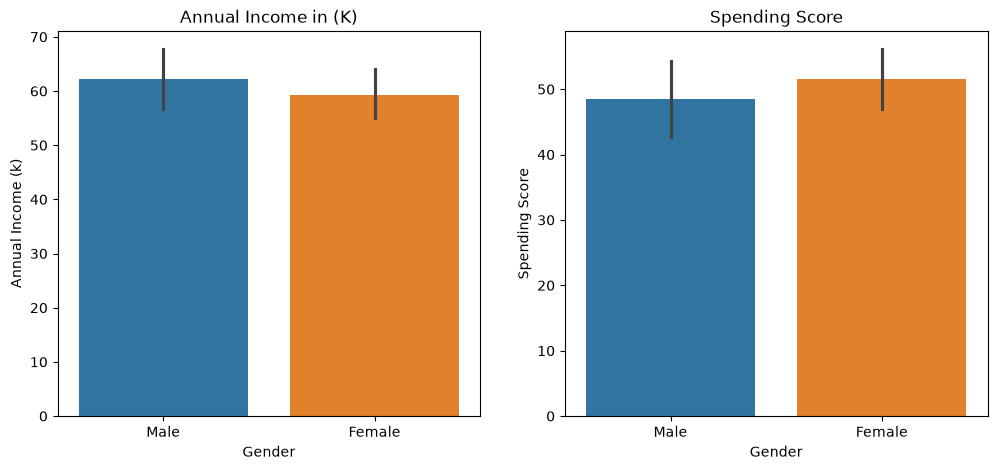

In [31]:
fig , axes =plt.subplots(1,2 , figsize=(12,5))

sns.barplot(data,x='Gender',y='Annual Income (k)',hue='Gender',legend=False,ax=axes[0])
axes[0].set_title("Annual Income in (K)")

sns.barplot(data, x="Gender" , y="Spending Score" , hue="Gender" ,legend=False )
axes[1].set_title("Spending Score")

plt.show()

### Comparing earning and spending based on age

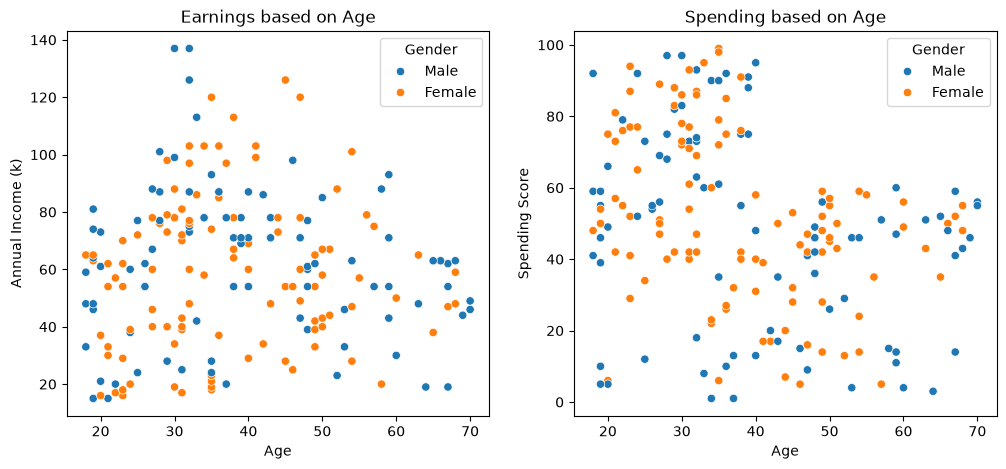

In [33]:
fig , axes =plt.subplots(1,2 ,figsize=(12,5))

sns.scatterplot(data ,x='Age' ,y='Annual Income (k)',hue='Gender',ax=axes[0])
axes[0].set_title("Earnings based on Age")

sns.scatterplot(data ,x='Age' ,y='Spending Score',hue='Gender')
axes[1].set_title("Spending based on Age")

plt.show()


## Finding density 

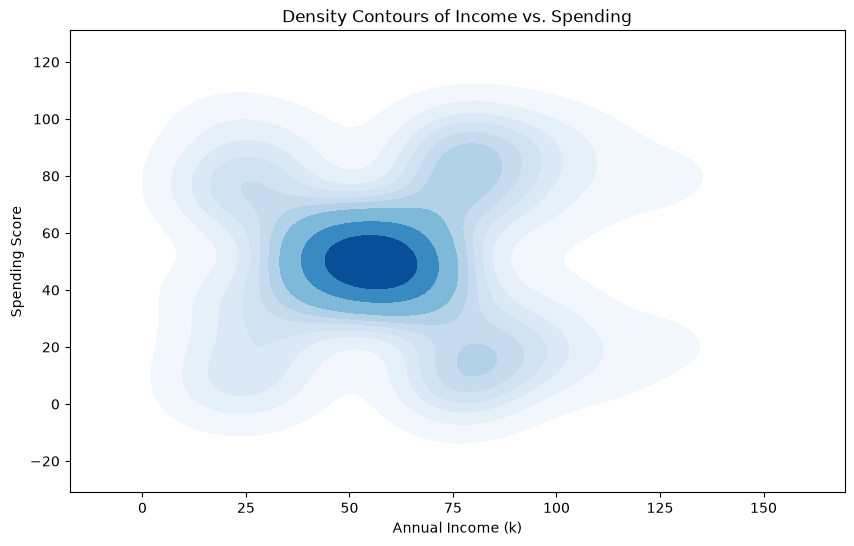

In [34]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=data, 
    x='Annual Income (k)', 
    y='Spending Score', 
    cmap='Blues', 
    fill=True, 
    thresh=0.05, 
    levels=10
)
plt.title('Density Contours of Income vs. Spending')
plt.show()

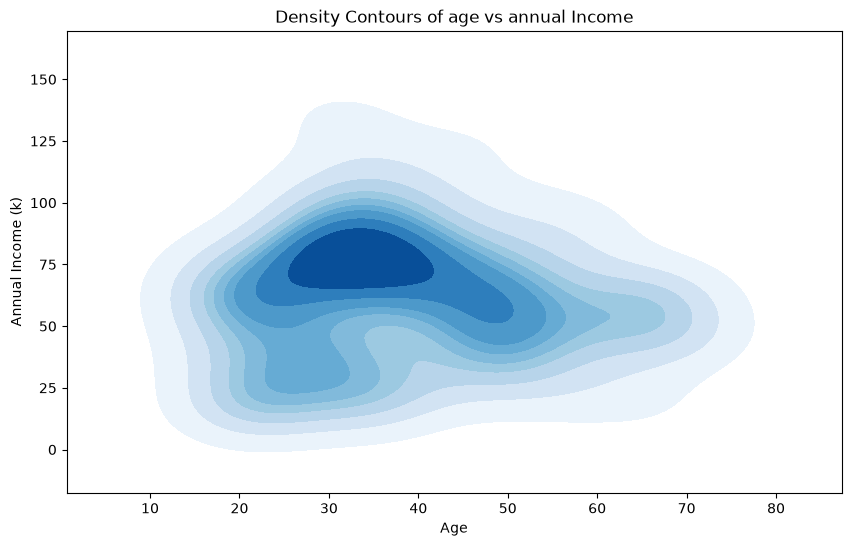

In [36]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=data, 
    x='Age', 
    y='Annual Income (k)', 
    cmap='Blues', 
    fill=True, 
    thresh=0.05, 
    levels=10
)
plt.title('Density Contours of age vs annual Income')
plt.show()

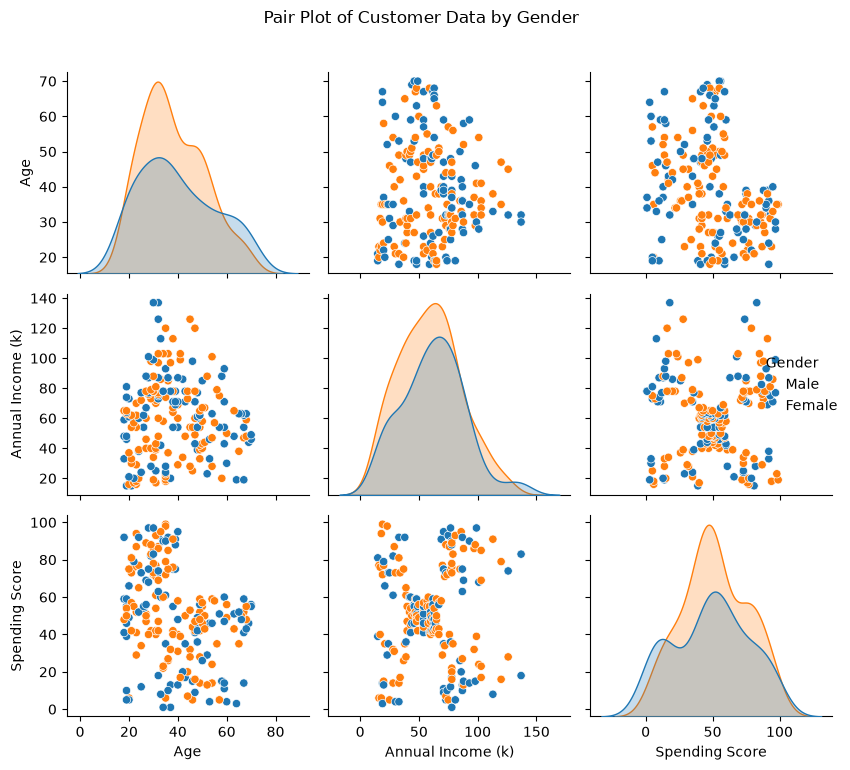

In [ ]:
sns.pairplot(data, hue='Gender', vars=['Age', 'Annual Income (k)', 'Spending Score'])
plt.suptitle('Pair Plot of Customer Data by Gender', y=1.02) 
plt.tight_layout()
plt.show()

## Observations 
- Male are earning more and women are spending more 
- Younger Age people are earning and spending more 
- most of the people of age 25 to 45 earn in range 70 to 80 k Annualy
- clear clusters can be seen betwen Annual Income and spending score 
- After age 40 ,the spending score is not more than 60 .

In [37]:
data.to_csv(DATA_DIR_PROCESS/"Mall_Customers_Data.csv")